<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
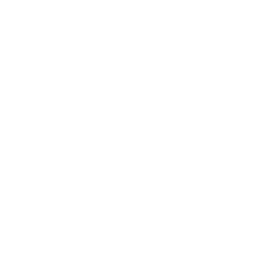
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Análisis de Fiabilidad de Equipos por Generación</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufactura / Ingeniería de Fiabilidad &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este análisis usa **PROC LIFETEST** para comparar la fiabilidad en campo de
tres generaciones sucesivas de diseño de fresadoras CNC. Partiendo de
una instantánea de 100 máquinas de una planta (75 fallas, 25 unidades
todavía en funcionamiento y por lo tanto censuradas por la derecha),
estima la curva de supervivencia de Kaplan-Meier para cada generación
y comprueba si las curvas difieren tanto con la estadística de log-rank
como con la de Gehan-Breslow-Wilcoxon.

Los datos cuentan una historia clara, de un solo paso. Las máquinas
originales de **GEN_1** son notablemente menos fiables que los dos
diseños posteriores: su vida útil media de servicio es de
**5,282 horas de funcionamiento**, aproximadamente un tercio de
**GEN_2** (**16,430 horas**) y **GEN_3** (**13,512 horas**). Ambas
pruebas de homogeneidad rechazan la igualdad de las tres curvas de
supervivencia -- chi-cuadrado de log-rank **12.92** (2 gl, *p* =
**0.0016**) y Wilcoxon **11.88** (2 gl, *p* = **0.0026**). A las
10,000 horas de funcionamiento, se espera que solo el **24%** de las
máquinas GEN_1 sigan en funcionamiento, frente al **64%** de GEN_2 y
el **57%** de GEN_3.

La mejora **no** es una ganancia suave generación tras generación:
GEN_2 y GEN_3 sobreviven a tasas muy similares y son estadísticamente
indistinguibles entre sí en este tamaño de muestra. El hallazgo
accionable es el cambio brusco de GEN_1 a la flota rediseñada, que
debería impulsar las prioridades de reemplazo y mantenimiento
preventivo hacia las unidades GEN_1 restantes.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | Una fila por máquina CNC: generación de diseño, planta, año de instalación, horas de funcionamiento en la falla o última observación, e indicador de falla / censura | 100 |

El conjunto de datos es sintético y se genera en la siguiente celda con
una semilla fija (`streaminit(42)`) para que el análisis sea totalmente
reproducible. La vida de servicio se extrae de un modelo exponencial
específico de cada generación, y las generaciones más nuevas llevan una
fracción de censura más alta porque han pasado menos años calendario
en servicio.

---

In [1]:
/* --------------------------------------------------------
   Genera un conjunto de datos sintetico de fiabilidad de equipos.

   Cada fila es una fresadora CNC. OPERATING_HOURS es el tiempo de
   servicio en el que la maquina fallo (FAILURE_EVENT=1) o fue
   observada por ultima vez en funcionamiento (FAILURE_EVENT=0,
   censurada por la derecha). Se asignan tres generaciones de diseno
   con vidas medias progresivamente mayores para poder preguntar si
   los rediseños realmente mejoraron la fiabilidad en campo.

   Este entorno sin licencia limita la salida a 100 observaciones, por
   lo que modelamos exactamente 100 maquinas -- una instantanea
   realista de una sola planta.
   -------------------------------------------------------- */
DATOS work.equipment_life;
    LLAMAR streaminit(42);
    LONGITUD generation $6 plant_location $14 failure_mode $10;
    ARREGLO fail_scale[3]       _temporary_ (8000 12000 16000);
    HACER equip_seq = 1 HASTA 100;
        equipment_id = cat('CNC-', PUT(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        SI gen_idx = 1 ENTONCES generation = 'GEN_1';
        SINO SI gen_idx = 2 ENTONCES generation = 'GEN_2';
        SINO generation = 'GEN_3';
        plant_idx       = int(rand('uniform') * 5) + 1;
        SI plant_idx = 1 ENTONCES plant_location = 'PLANTA_NORTE';
        SINO SI plant_idx = 2 ENTONCES plant_location = 'PLANTA_SUR';
        SINO SI plant_idx = 3 ENTONCES plant_location = 'PLANTA_ESTE';
        SINO SI plant_idx = 4 ENTONCES plant_location = 'PLANTA_OESTE';
        SINO plant_location = 'PLANTA_CENTRAL';
        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* Vida de servicio exponencial, escalada por generacion */
        operating_hours = round(rand('exponential')
                                * fail_scale[gen_idx] + 500, 1);
        /* Las generaciones mas nuevas llevan mas unidades todavia en
           funcionamiento (censuradas) porque han pasado menos anos
           calendario en el campo. */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        SI rand('uniform') < censor_rate ENTONCES failure_event = 0;
        SINO                                  failure_event = 1;
        /* Clasifica el mecanismo de falla para los eventos observados */
        SI failure_event = 1 ENTONCES HACER;
            SI      operating_hours <  2000 ENTONCES failure_mode = 'INFANTIL';
            SINO SI operating_hours < 20000 ENTONCES failure_mode = 'ALEATORIO';
            SINO                                 failure_mode = 'DESGASTE';
        END;
        SINO failure_mode = ' ';
        SALIDA;
    END;
    ELIMINAR equip_seq gen_idx plant_idx censor_rate;
EJECUTAR;


NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of Generacion by Evento de Falla

Generacion |         0 |         1 |      Total
-----------+-----------+-----------+-----------
GEN_1      |         2 |        29 |         31
-----------+-----------+-----------+-----------
GEN_2      |        12 |        26 |         38
-----------+-----------+-----------+-----------
GEN_3      |        11 |        20 |         31
-----------+-----------+-----------+-----------
Total      |        25 |        75 |        100


Table of Generacion by Modo de Falla

Generacion |           | ALEATORIO |  DESGASTE |  INFANTIL |      Total
-----------+-----------+-----------+-----------+-----------+-----------
GEN_1      |         2 |        21 |         3 |         5 |         31
           |      2.00 |     21.00 |      3.00 |      5.00 |      31.00
-----------+-----------+-----------+-----------+-----------+-----------
GEN_2      |        12 |        19 |         6 |         


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


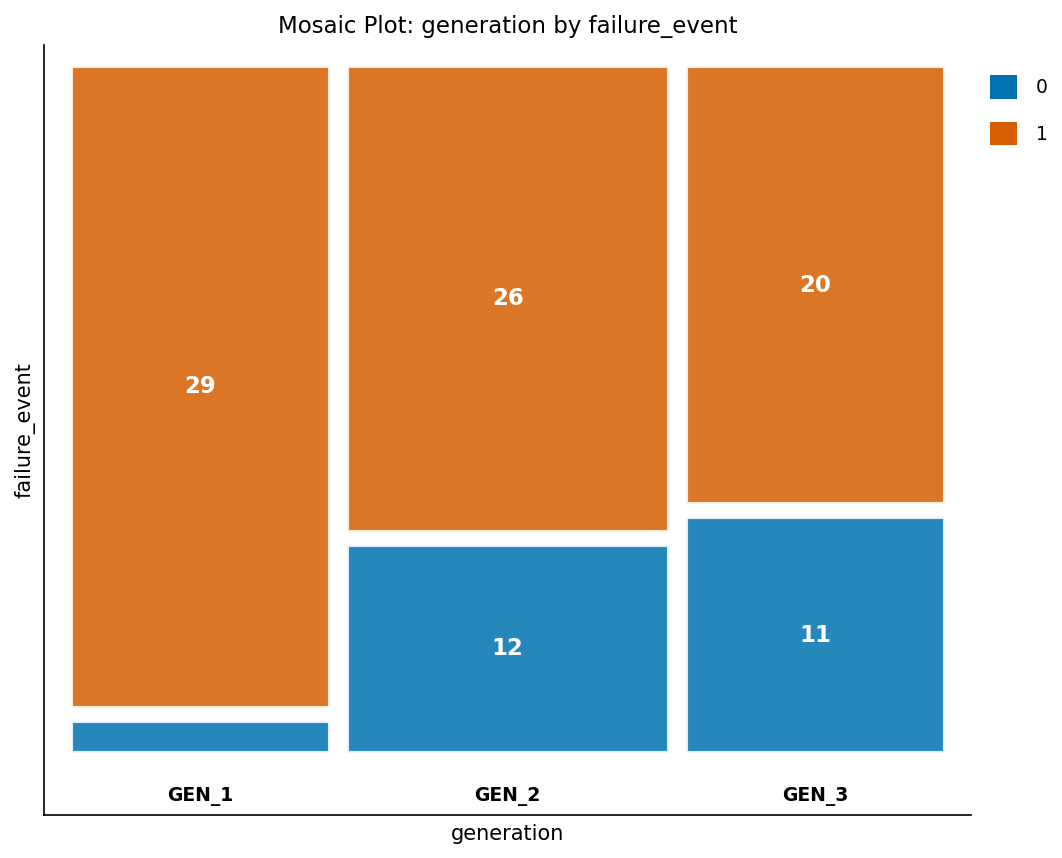

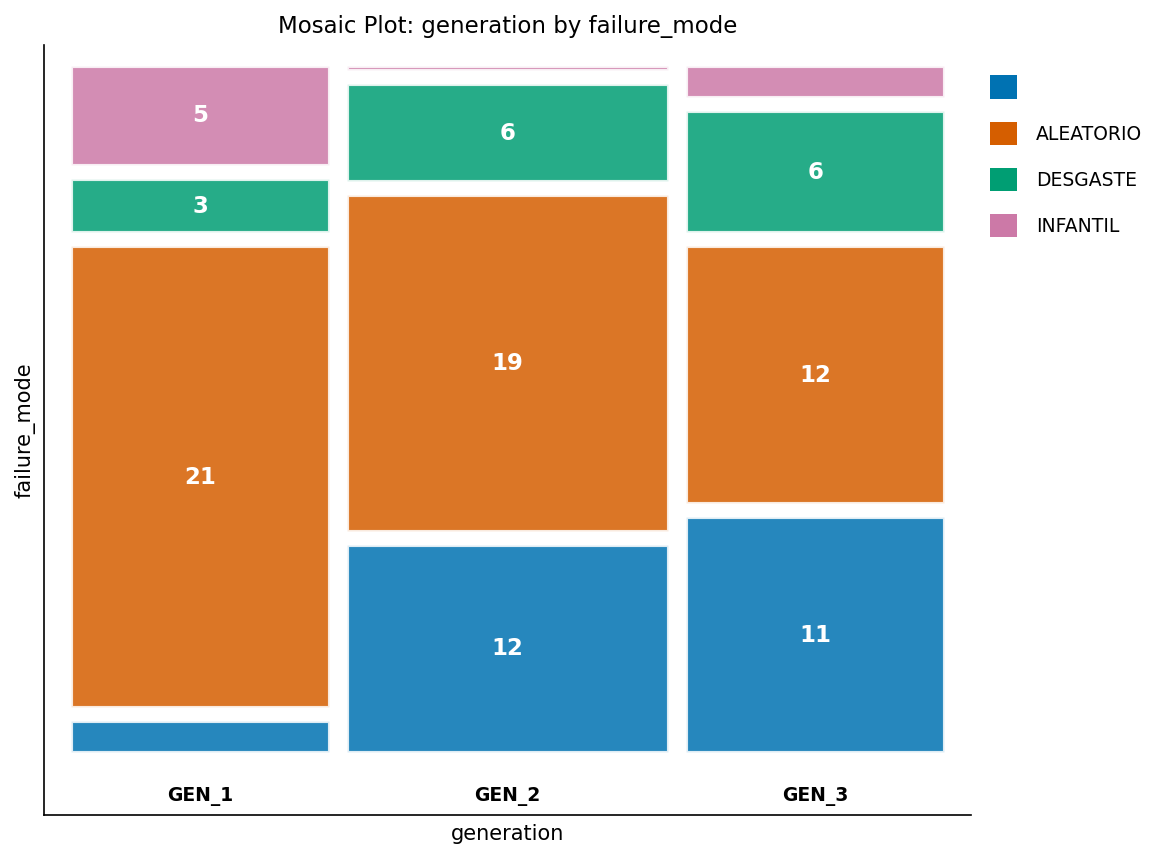

In [2]:
/* --------------------------------------------------------
   Recuentos y horas de funcionamiento basicos por generacion
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.equipment_life;
    ETIQUETA generation='Generacion' failure_event='Evento de Falla' failure_mode='Modo de Falla';
    TABLES generation * failure_event / nocol nopercent;
    TABLES generation * failure_mode / nocol norow;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.equipment_life n mean std;
    ETIQUETA operating_hours='Horas de Funcionamiento' generation='Generacion';
    CLASE generation;
    VAR operating_hours;
EJECUTAR;

---


NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


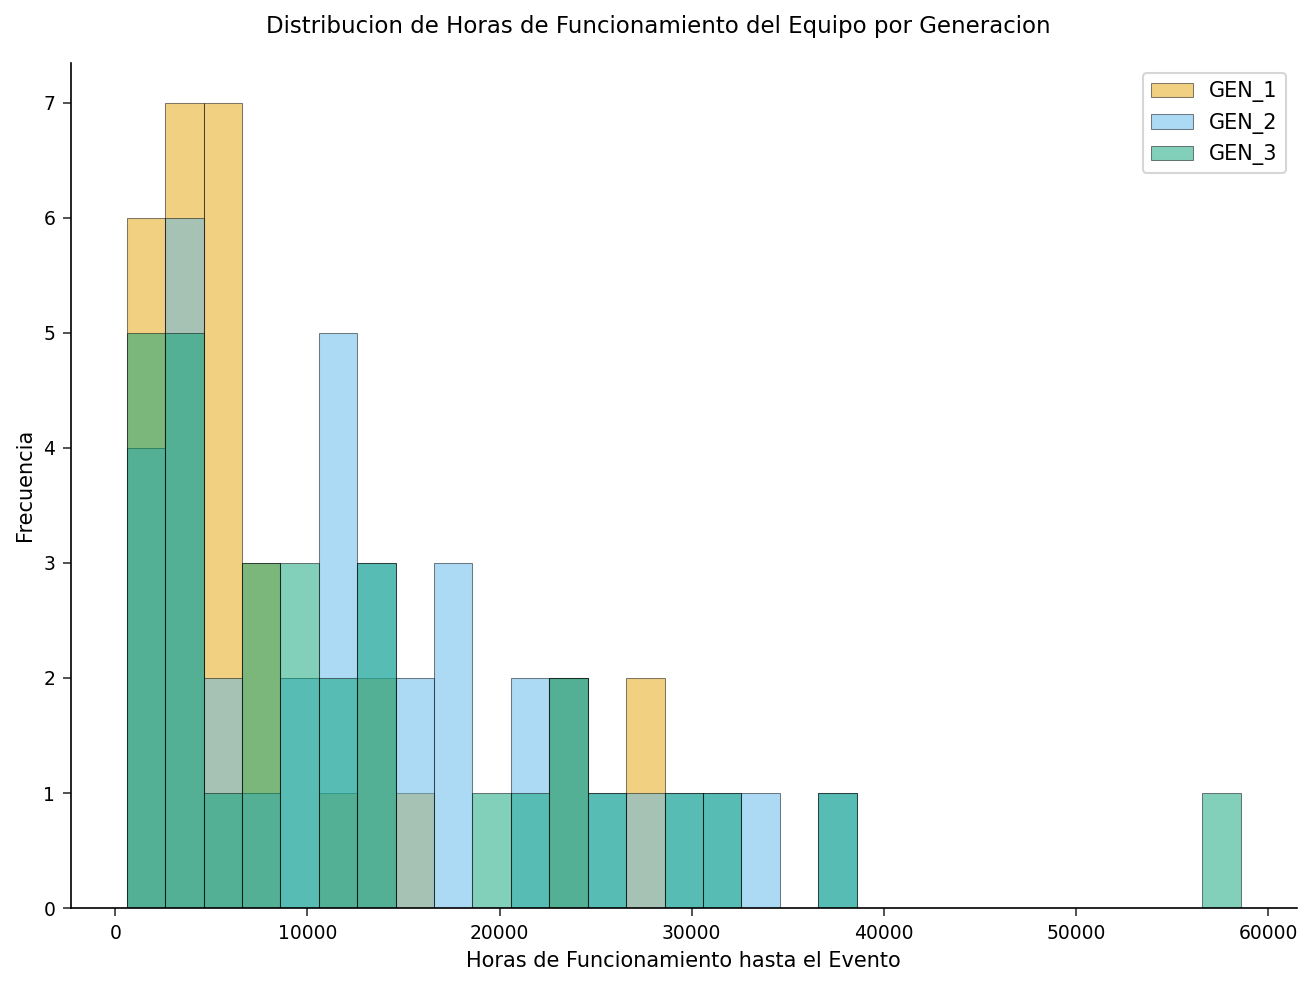

In [3]:
/* --------------------------------------------------------
   Distribucion de horas de funcionamiento por generacion
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.equipment_life;
    HISTOGRAM operating_hours / GROUP=generation TRANSPARENCY=0.3 BINWIDTH=2000;
    XAXIS label='Horas de Funcionamiento hasta el Evento';
    YAXIS label='Frecuencia';
    TÍTULO 'Distribucion de Horas de Funcionamiento del Equipo por Generacion';
EJECUTAR;

---

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

  Stratum: Generacion = GEN_1  

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.806


NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/e9dd5c3b-65f2-4f37-90cb-a644443638b5/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


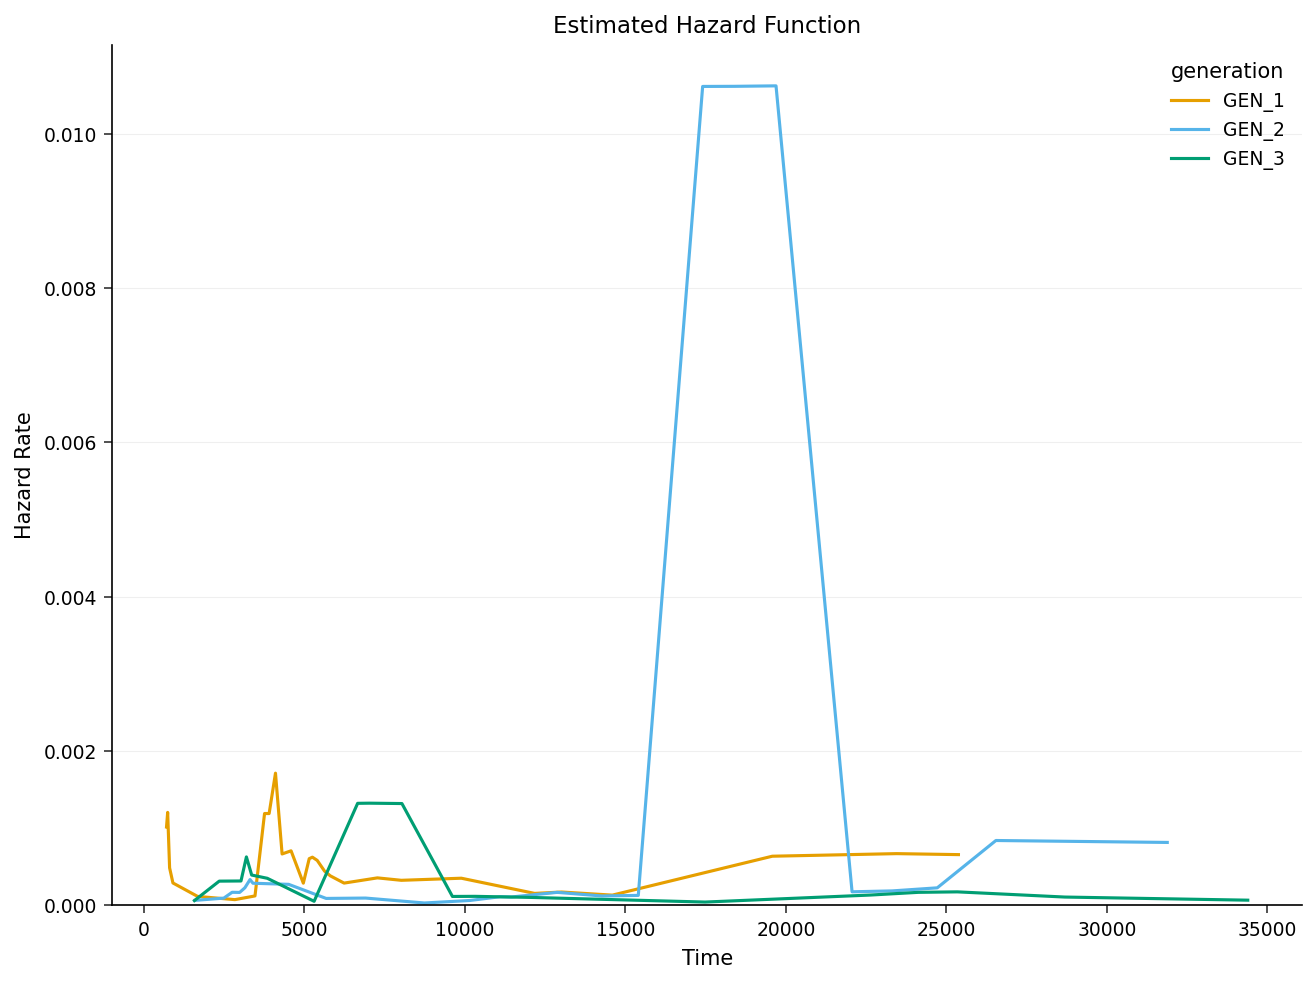

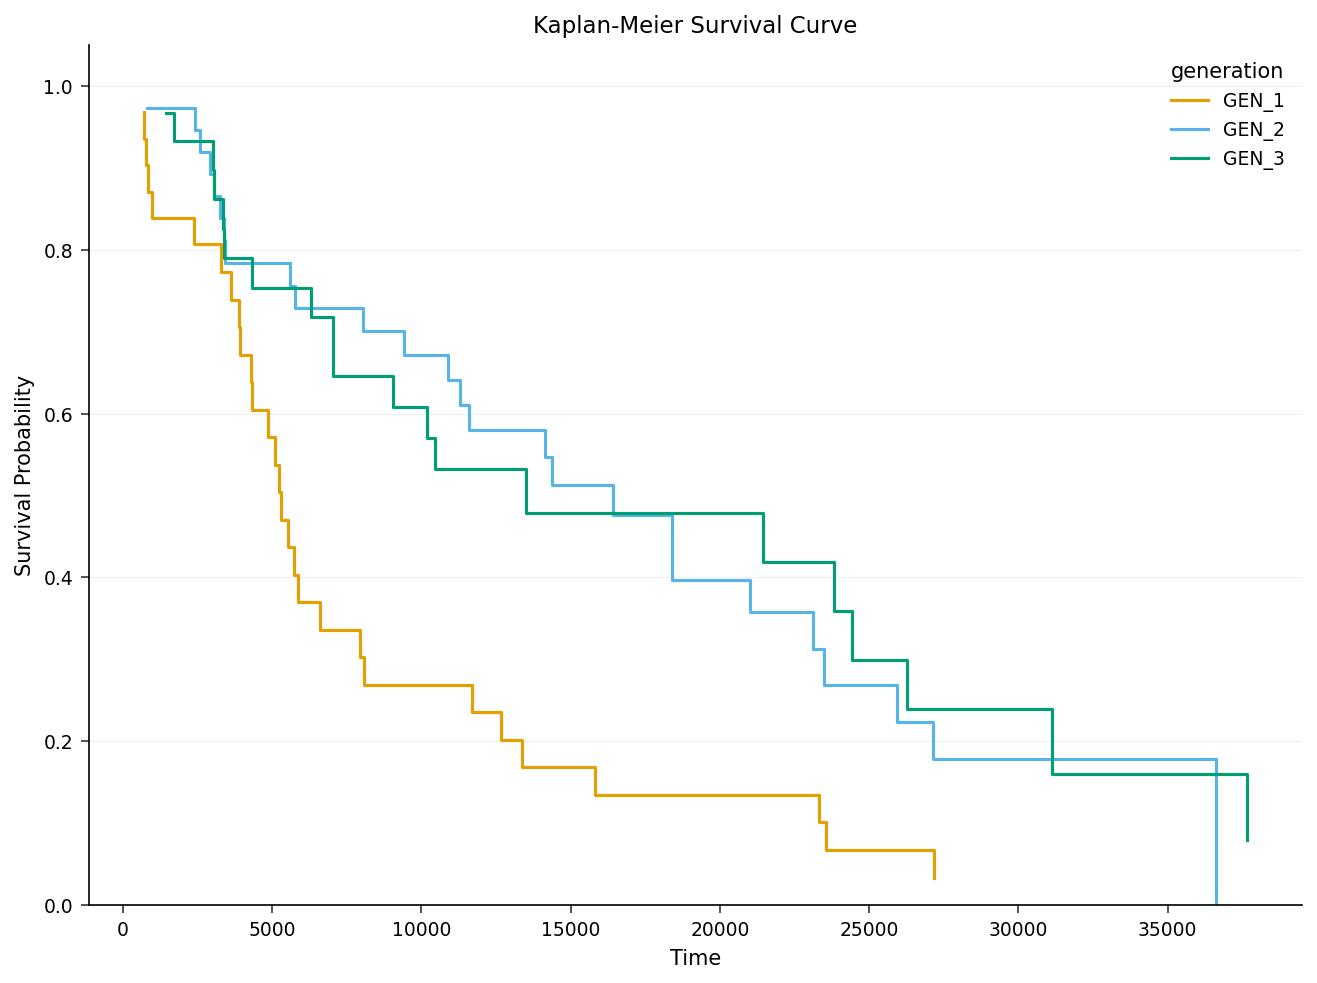

In [4]:
/* --------------------------------------------------------
   Estimacion de supervivencia de Kaplan-Meier por generacion, con
   la opcion de riesgo acumulado de Nelson-Aalen para la vista de
   riesgo.

   STRATA generation / TEST=(LOGRANK WILCOXON) ejecuta tanto la
   prueba de log-rank (sensible a diferencias a lo largo de toda la
   vida de servicio) como la prueba de Gehan-Breslow-Wilcoxon (que
   da mas peso a las fallas tempranas) sobre las tres generaciones.

   PLOTS=(SURVIVAL HAZARD) dibuja las curvas de supervivencia de
   Kaplan-Meier y la funcion de riesgo suavizada por nucleo.
   -------------------------------------------------------- */
PROCEDIMIENTO LIFETEST DATOS=work.equipment_life
    METHOD=km
    nelson
    PLOTS=(SURVIVAL hazard)
    outsurv=work.equip_cumhaz;
    ETIQUETA generation='Generacion';
    TIME operating_hours * failure_event(0);
    STRATA generation / TEST=(logrank WILCOXON);
EJECUTAR;

In [5]:
/* --------------------------------------------------------
   Probabilidad de supervivencia en los hitos de horas de
   funcionamiento (5,000 / 10,000 / 20,000 / 30,000 horas) para
   cada generacion, leidos de la tabla ODS de Kaplan-Meier.
   -------------------------------------------------------- */
ODS SALIDA productlimitestimates=work.equip_km_detail;

PROCEDIMIENTO LIFETEST DATOS=work.equipment_life METHOD=km;
    TIME operating_hours * failure_event(0);
    STRATA generation;
EJECUTAR;

ODS SALIDA CLOSE;

/* La tabla ProductLimitEstimates lleva una fila por tiempo distinto
   dentro de cada generacion. Para cada hito conservamos la primera
   fila cuyo tiempo esta en o mas alla de el -- es decir, la
   estimacion de supervivencia vigente en esa hora de funcionamiento. */
PROCEDIMIENTO ORDENAR DATOS=work.equip_km_detail;
    POR generation operating_hours;
EJECUTAR;

DATOS work.equip_milestones;
    ESTABLECER work.equip_km_detail;
    POR generation;
    RETENER hit5 hit10 hit20 hit30;
    SI first.generation ENTONCES HACER;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    END;
    LONGITUD milestone 8;
    milestone = .;
    SI      operating_hours >= 5000  AND hit5  = 0 ENTONCES HACER; milestone = 5000;  hit5  = 1; END;
    SINO SI operating_hours >= 10000 AND hit10 = 0 ENTONCES HACER; milestone = 10000; hit10 = 1; END;
    SINO SI operating_hours >= 20000 AND hit20 = 0 ENTONCES HACER; milestone = 20000; hit20 = 1; END;
    SINO SI operating_hours >= 30000 AND hit30 = 0 ENTONCES HACER; milestone = 30000; hit30 = 1; END;
    SI milestone ne .;
    MANTENER generation milestone operating_hours SURVIVAL sdf_stderr;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.equip_milestones noobs ETIQUETA;
    ETIQUETA generation     = 'Generacion'
          milestone       = 'Hito (horas)'
          operating_hours = 'Tiempo de la Estimacion'
          SURVIVAL        = 'Probabilidad de Supervivencia'
          sdf_stderr      = 'Error Estandar';
    FORMATO SURVIVAL sdf_stderr 6.4;
    TÍTULO 'Probabilidad de Supervivencia en los Hitos de Horas de Funcionamiento por Generacion';
EJECUTAR;

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

  Stratum: generation = GEN_1  

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.806


NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---

### Interpretación

Las curvas de supervivencia de Kaplan-Meier separan la flota en dos
niveles claros. Las máquinas originales de **GEN_1** fallan más rápido:
su curva cae por debajo de 0.5 a las **5,282 horas de funcionamiento**
(vida útil media de servicio), y a las 10,000 horas solo alrededor del
**24%** sigue en funcionamiento. Las máquinas rediseñadas **GEN_2** y
**GEN_3** sobreviven mucho más tiempo -- vidas medias de **16,430** y
**13,512** horas respectivamente -- y sus curvas de supervivencia se
mantienen muy cercanas en todo el rango observado. En los hitos de
5,000 / 10,000 / 20,000 horas, las probabilidades de supervivencia
estimadas son:

| Generación | 5,000 h | 10,000 h | 20,000 h |
|------------|--------:|---------:|---------:|
| GEN_1 | 0.54 | 0.24 | 0.10 |
| GEN_2 | 0.76 | 0.64 | 0.36 |
| GEN_3 | 0.72 | 0.57 | 0.42 |

Ambas pruebas de igualdad de estratos rechazan la hipótesis nula de que
las tres generaciones comparten una distribución de supervivencia: la
prueba de **log-rank** da chi-cuadrado **12.92** (2 gl, *p* = **0.0016**)
y la prueba de **Gehan-Breslow-Wilcoxon** da chi-cuadrado **11.88**
(2 gl, *p* = **0.0026**). Las dos pruebas concuerdan de cerca, así que
la diferencia está impulsada por la mayor parte de la vida de servicio
y no solo por la región de falla temprana (la prueba de Wilcoxon da más
peso a los eventos tempranos).

Es importante leer esto como una mejora de **un solo paso**, no una
ganancia monótona generación tras generación. GEN_2 y GEN_3 son
estadísticamente indistinguibles aquí -- sus curvas se superponen y la
mediana de GEN_2 es nominalmente la más alta de las dos -- así que en
esta muestra de 100 máquinas no hay evidencia de que GEN_3 haya
mejorado sobre GEN_2. La señal real es la brecha grande y significativa
entre el diseño original GEN_1 y los dos diseños posteriores.

La opción de riesgo acumulado de Nelson-Aalen impulsa el gráfico de
riesgo complementario. En este tamaño de muestra, el riesgo suavizado
por núcleo es ruidoso -- el pico alto de GEN_2 cerca de las 18,000
horas refleja un único evento en un conjunto de riesgo remanente
pequeño, más que un genuino repunte de desgaste -- por lo que la vista
de riesgo debe tratarse como cualitativa; las curvas de supervivencia y
las pruebas formales llevan las conclusiones cuantitativas.

**Recomendación.** Priorizar el reemplazo y la inspección más estricta
de las máquinas GEN_1 restantes, cuya fiabilidad es materialmente peor
que la del resto de la flota. Tratar GEN_2 y GEN_3 como una sola
cohorte más fiable para la planificación de mantenimiento hasta que
una muestra más grande pueda resolver cualquier diferencia entre
ellas.

---

In [6]:
/* --------------------------------------------------------
   Exporta los datos de riesgo acumulado / curva de supervivencia y
   la tabla de supervivencia por hitos para un panel de fiabilidad
   posterior.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.equip_cumhaz
    OUTFILE='equipment_cumulative_hazard.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.equip_milestones
    OUTFILE='equipment_milestone_survival.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>